In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

In [3]:
# Linear Regression on California Housing Data
housing_data = fetch_california_housing()
dir(housing_data)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [4]:
# Create a dataframe
df_housing = pd.DataFrame(housing_data.data, columns = housing_data.feature_names)
df_housing['PRICE'] = housing_data.target
print(df_housing.head(5))

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [9]:
X_reg = df_housing.drop('PRICE', axis = 1)
y_reg = df_housing['PRICE']

In [10]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size = 0.2, random_state = 42
)

In [11]:
lin_model = LinearRegression()
print("\n Training Linear Regression Model")
lin_model.fit(X_train_reg, y_train_reg)


 Training Linear Regression Model


LinearRegression()

In [13]:
y_pred_reg = lin_model.predict(X_test_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Linear Model mse: {mse:.4f}")
print(f"Linear Model r2 Score: {r2:.4f}")

Linear Model mse: 0.5559
Linear Model r2 Score: 0.5758


Text(0.5, 1.0, 'Linear Regression: Actual vs Predicted Prices')

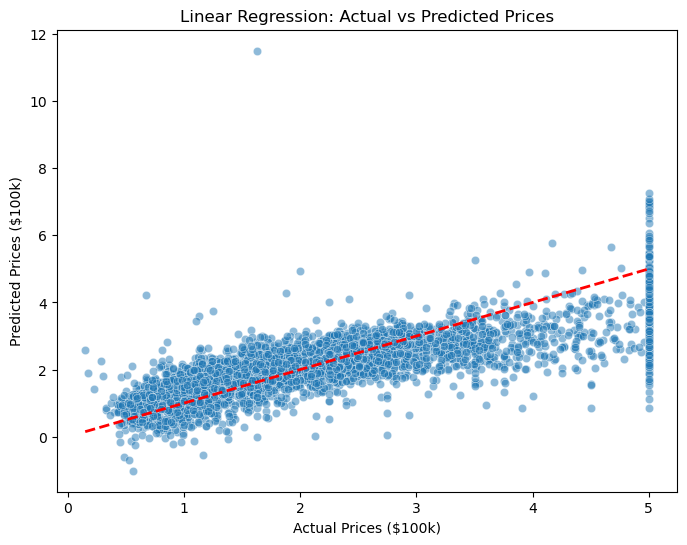

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha = 0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel("Actual Prices ($100k)")
plt.ylabel("Predicted Prices ($100k)")
plt.title("Linear Regression: Actual vs Predicted Prices")